# Notebook 05 - CNN Training for ECG Classification

## Objective
Train a Convolutional Neural Network (CNN) to classify ECG signals.

## Scope
This notebook performs:
- dataset loading
- shape inspection
- train/validation/test split
- optional normalization
- CNN model definition
- model training
- learning curves visualization
- final evaluation

⚠️ Adjust file paths and label mapping according to your project files.

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 1. File paths

Adjust these paths to your local files.

In [9]:
X_path = '../data/processed/cnn_X.npy'
y_path = '../data/processed/cnn_y.csv'

print('X exists:', os.path.exists(X_path))
print('y exists:', os.path.exists(y_path))

X exists: True
y exists: True


In [10]:
if not os.path.exists(X_path):
    raise FileNotFoundError(f'File not found: {X_path}')

if not os.path.exists(y_path):
    raise FileNotFoundError(f'File not found: {y_path}')

X = np.load(X_path)

y_df = pd.read_csv(y_path)

# usa apenas a coluna de rótulo
y = y_df['arrhythmia_label'].astype(str).values

print('X shape:', X.shape)
print('y shape:', y.shape)
print('X dtype:', X.dtype)
print('y dtype:', y.dtype)
print('Primeiros labels:', y[:10])

X shape: (23005, 3600)
y shape: (23005,)
X dtype: float32
y dtype: object
Primeiros labels: ['supraventricular' 'supraventricular' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal']


## 2. Dataset inspection

In [11]:
unique_labels, counts = np.unique(y, return_counts=True)
distribution = pd.DataFrame({'label': unique_labels, 'count': counts})
distribution['percentage'] = 100 * distribution['count'] / distribution['count'].sum()
distribution.sort_values('label')

,label,count,percentage
0,fusion,72,0.312975
1,normal,15737,68.406868
2,other,614,2.668985
3,supraventricular,1589,6.907194
4,ventricular,4993,21.703977


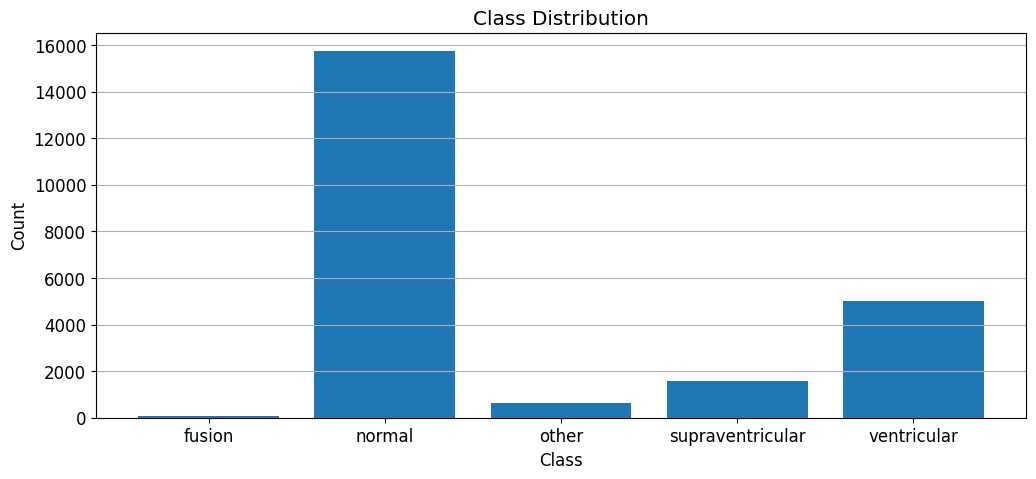

In [12]:
plt.figure()
plt.bar(distribution['label'].astype(str), distribution['count'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.grid(True, axis='y')
plt.show()

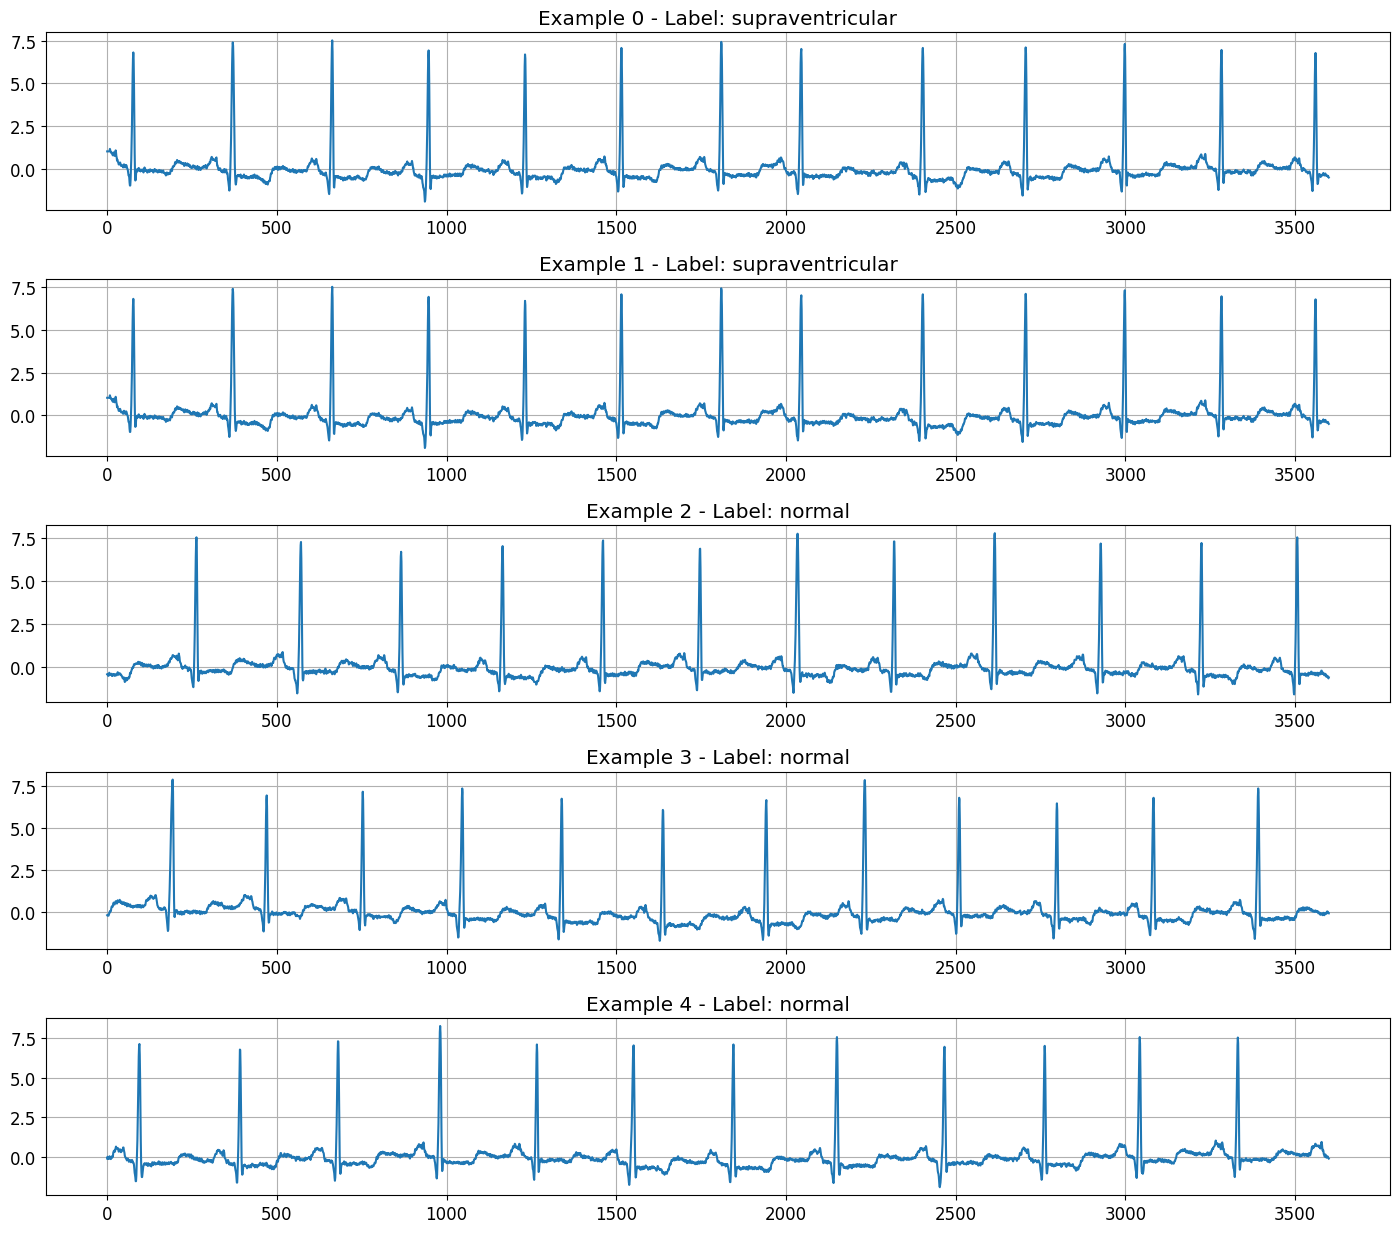

In [13]:
# Show a few signals
n_examples = min(5, len(X))
fig, axes = plt.subplots(n_examples, 1, figsize=(14, 2.5 * n_examples), sharex=False)

if n_examples == 1:
    axes = [axes]

for i in range(n_examples):
    signal = X[i]
    if signal.ndim > 1:
        signal = signal.squeeze()
    axes[i].plot(signal)
    axes[i].set_title(f'Example {i} - Label: {y[i]}')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## 3. Data preparation

In [14]:
# Ensure input format is (samples, timesteps, channels)
if X.ndim == 2:
    X = X[..., np.newaxis]
elif X.ndim == 3:
    pass
else:
    raise ValueError(f'Unsupported X shape: {X.shape}')

print('Adjusted X shape:', X.shape)

Adjusted X shape: (23005, 3600, 1)


In [15]:
# Normalize per sample (z-score)
X_mean = X.mean(axis=1, keepdims=True)
X_std = X.std(axis=1, keepdims=True) + 1e-8
X_norm = (X - X_mean) / X_std

print('Normalized X shape:', X_norm.shape)

Normalized X shape: (23005, 3600, 1)


In [16]:
# Train / validation / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('X_train:', X_train.shape)
print('X_val:  ', X_val.shape)
print('X_test: ', X_test.shape)
print('y_train:', y_train.shape)
print('y_val:  ', y_val.shape)
print('y_test: ', y_test.shape)

X_train: (16103, 3600, 1)
X_val:   (3451, 3600, 1)
X_test:  (3451, 3600, 1)
y_train: (16103,)
y_val:   (3451,)
y_test:  (3451,)


In [17]:
# Encode labels if they are not already integers from 0..N-1
label_values = np.unique(y)
label_to_index = {label: idx for idx, label in enumerate(label_values)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

y_train_enc = np.array([label_to_index[v] for v in y_train])
y_val_enc   = np.array([label_to_index[v] for v in y_val])
y_test_enc  = np.array([label_to_index[v] for v in y_test])

num_classes = len(label_values)

print('Classes:', label_values)
print('Label mapping:', label_to_index)
print('Number of classes:', num_classes)

Classes: ['fusion' 'normal' 'other' 'supraventricular' 'ventricular']
Label mapping: {'fusion': 0, 'normal': 1, 'other': 2, 'supraventricular': 3, 'ventricular': 4}
Number of classes: 5


## 4. CNN model definition

In [18]:
input_shape = X_train.shape[1:]

model = Sequential([
    Conv1D(32, kernel_size=5, activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Projetos\PFE\Software\pfe_ecg\.venv-cnn\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3596, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3596, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1798, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1794, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1794, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 897, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 895, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 895, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 447, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57216)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,323,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,360,517 (28.08 MB)

 Trainable params: 7,360,069 (28.08 MB)

 Non-trainable params: 448 (1.75 KB)

## 5. Training

In [19]:
os.makedirs('../models', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('../models/cnn_ecg_best.keras', monitor='val_loss', save_best_only=True)
]

history = model.fit(
    X_train, y_train_enc,
    validation_data=(X_val, y_val_enc),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 147s 286ms/step - accuracy: 0.7167 - loss: 0.8884 - val_accuracy: 0.6940 - val_loss: 9.1170
Epoch 2/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 121s 239ms/step - accuracy: 0.8243 - loss: 0.5002 - val_accuracy: 0.7853 - val_loss: 0.7823
Epoch 3/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 115s 228ms/step - accuracy: 0.8775 - loss: 0.3413 - val_accuracy: 0.7969 - val_loss: 0.9074
Epoch 4/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 116s 231ms/step - accuracy: 0.9152 - loss: 0.2488 - val_accuracy: 0.9050 - val_loss: 0.3268
Epoch 5/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 123s 244ms/step - accuracy: 0.9248 - loss: 0.2112 - val_accuracy: 0.8516 - val_loss: 0.7100
Epoch 6/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 128s 255ms/step - accuracy: 0.9429 - loss: 0.1597 - val_accuracy: 0.8687 - val_loss: 0.3999
Epoch 7/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 126s 250ms/step - accuracy: 0.9494 - loss: 0.1432 - val_accuracy: 0.6314 - val_loss: 1.1242
Epoch 8/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 127s 252ms/step - accuracy: 0.9565 -

## 6. Learning curves

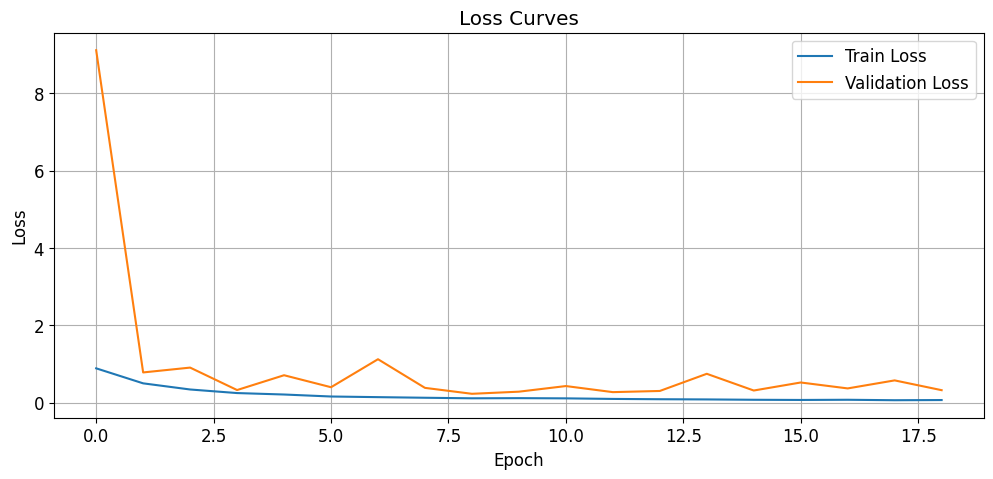

In [20]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

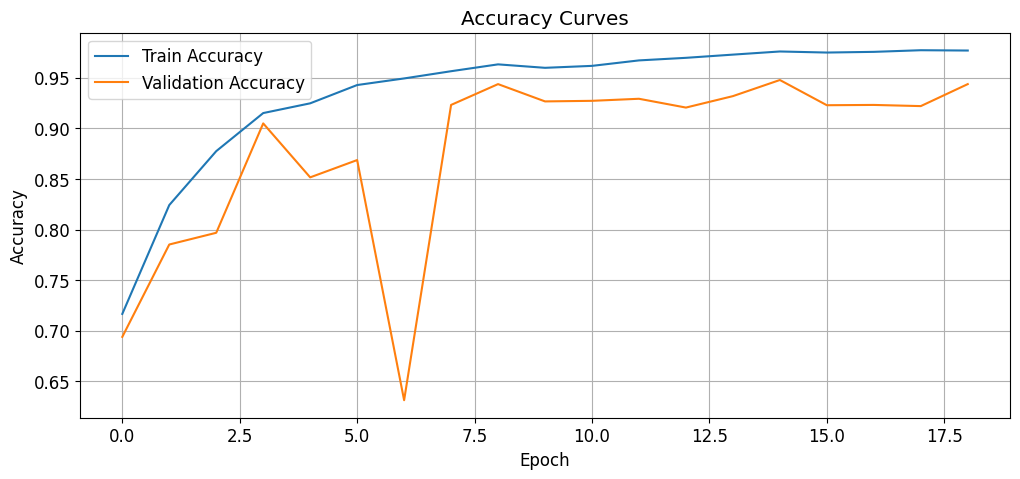

In [21]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 7. Test evaluation

In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test_enc, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

Test loss: 0.2509
Test accuracy: 0.9348


In [23]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred_enc = np.argmax(y_pred_prob, axis=1)

print(classification_report(
    y_test_enc,
    y_pred_enc,
    target_names=[str(index_to_label[i]) for i in range(num_classes)]
))

                  precision    recall  f1-score   support

          fusion       1.00      0.45      0.62        11
          normal       0.95      0.97      0.96      2361
           other       0.85      0.96      0.90        92
supraventricular       0.95      0.79      0.86       238
     ventricular       0.90      0.88      0.89       749

        accuracy                           0.93      3451
       macro avg       0.93      0.81      0.85      3451
    weighted avg       0.94      0.93      0.93      3451



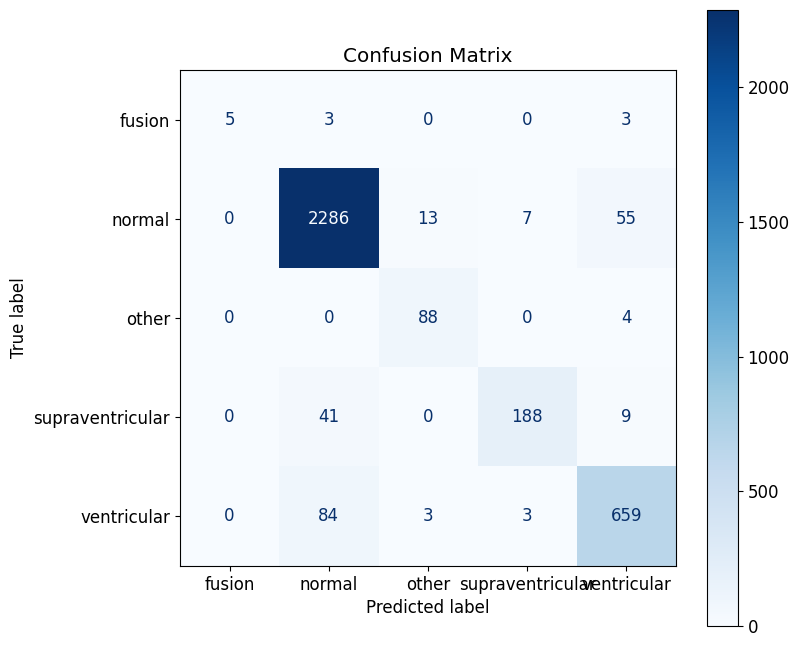

In [24]:
cm = confusion_matrix(y_test_enc, y_pred_enc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(index_to_label[i]) for i in range(num_classes)])

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

## 8. Save final model

In [25]:
model.save('../models/cnn_ecg_final.keras')
print('Saved model to ../models/cnn_ecg_final.keras')

Saved model to ../models/cnn_ecg_final.keras


## 9. Summary

In [26]:
summary = pd.DataFrame({
    'Metric': ['Train samples', 'Validation samples', 'Test samples', 'Classes', 'Test loss', 'Test accuracy'],
    'Value': [len(X_train), len(X_val), len(X_test), num_classes, test_loss, test_acc]
})
summary

,Metric,Value
0,Train samples,16103.000000
1,Validation samples,3451.000000
2,Test samples,3451.000000
3,Classes,5.000000
4,Test loss,0.250901
5,Test accuracy,0.934802


In [27]:
print('Notebook 05 - CNN Training completed successfully.')
print('Generated outputs:')
print('- Data split')
print('- CNN model')
print('- Training history')
print('- Final evaluation')
print('- Saved models in ../models/')

Notebook 05 - CNN Training completed successfully.
Generated outputs:
- Data split
- CNN model
- Training history
- Final evaluation
- Saved models in ../models/
